# Filter Bank Common Spatial Pattern and Common Spatial Patern Performanse Comparison
Attempt at implementing filter-bank common spatial filter (FBCSP) and CSP on BCI Competition IV 2a Dataset
  
**References:**   

[1] Kai Keng Ang, Zheng Yang Chin, Haihong Zhang and Cuntai Guan, "Filter Bank Common Spatial Pattern (FBCSP) in Brain-Computer Interface," 2008 IEEE International Joint Conference on Neural Networks (IEEE World Congress on Computational Intelligence), Hong Kong, 2008, pp. 2390-2397, doi: 10.1109/IJCNN.2008.4634130.    
[2] Ang, K. K., Chin, Z. Y., Wang, C., Guan, C., & Zhang, H. (2012). Filter Bank Common Spatial Pattern Algorithm on BCI Competition IV Datasets 2a and 2b. Frontiers in Neuroscience, 6. doi: 10.3389/fnins.2012.00039

# BCI Competition IV Dataset 2a (.npz data)
Information Given in Documentation

From the documentation it is known that:
* 25 electrodes are used, first 22 are EEG, last 3 are EOG
* Sampling frequency (fs) is 250Hz
* 9 subjects
* 9 run (run 1-3 are for eye movement, run 4-9 is MI)  
  

**-- Time Duration--**  
1 trials                          = 7-8s  
1 run              = 48 trials    = 336-384s  
1 session = 6 runs = 288 trials   = 2016-2304s

About the recording of eye movement
* run 1 => 2 mins with eyes open
* run 2 => 1 min with eyes closed
* run 3 => 1 min with eye movements

![timing-scheme-paradigm.png](./img/timing-scheme-paradigm.png) 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Subject and window selection

Select which of the 9 subjects should be included in the classification and the window of trial analysis. 

The variable `m` represents the number of spatial filters to be selected for the analysis. Since each spatial filter corresponds to a channel, `2*m` indicates the total number of channels (or spatial filters) used. This includes the `m` filters with the highest eigenvalues and the `m` filters with the lowest eigenvalues, which are typically the most informative for class discrimination in CSP (Common Spatial Pattern) algorithm.

In [2]:
# Define subjects for analysis
sub_start = 1  # starting subject number
sub_end = 9  # ending subject number
sub_end = sub_end + 1 # for iteration purpose

# Define window start and end - start and end time in seconds after cue onset of each class
start = 0.5 # 0.5s after cue onset is common practice in EEG analysis, to avoid pre-stimulus noise
end = 2
# Select number of filters, 2*m is the number of channels to be used for the analysis
m = 6

# Selecting Events for Classification 

Select the events to classify the motor imagery - classes, based on the following codes: 
* 768 - Start of a trial 
* 769 - Cue onset left
* 770 - Cue onset right
* 771 - Cue onset foot
* 772 - Cue onset tongue


In [3]:
rest_code = 768 # new trial
left_code = 769
right_code = 770
foot_code = 771
tongue_code = 772

movement_code = [left_code, right_code, foot_code, tongue_code]

classification_combinations = [
    ([left_code], [right_code], 'Left', 'Right'),
    ([left_code], [rest_code], 'Left', 'Rest'),
    ([right_code], [rest_code], 'Right', 'Rest'),
    ([left_code, right_code, foot_code, tongue_code], [rest_code], 'Movement', 'Rest')
]

The following classifications are expected to be analysed:

    left / right  
    movement / rest  
    left / rest  
    right / rest  


In [4]:
# Assign desired event to a class

first_class_code = rest_code
second_class_code = movement_code


# Loading dataset

In [5]:
# Number of subject, n + 1 for iteration purpose (there are 9 subjects)
ns = 10

# Creating dict to store original data and modified data
# ori_data will serve as initial loaded data that will remain unchanged
# mod_data will contain modified original data
ori_data = dict()
mod_data = dict() 

# Function to count subject
def subject_counter(i):
    return 'subject0{}'.format(i)

# Access directory where the data is stored (change if needed)
base_dir = os.getcwd()



In [6]:
# Load the training data of all subjects

# Iter over all data path then store them in sub0X variable
for i in range(1, ns):
    data_path = os.path.join(base_dir, 'datasets/A{:02d}T.npz'.format(i))
    subject = 'subject{:02d}'.format(i)
    
    # Load EEG data from datapath and store into subj0X variabel then store into data dictionary
    ori_data[subject] = np.load(data_path)

In [7]:
# Loading the evaluation data of all subjects (LATER)
eval_data = dict()  # Create a separate dictionary for evaluation data
for i in range(1, ns):
    data_path = os.path.join(base_dir, 'datasets/A{:02d}E.npz'.format(i))
    subject = 'subject{:02d}'.format(i)
    
    # Load EEG data from datapath and store into eval_data dictionary
    eval_data[subject] = np.load(data_path)

Explanation regarding contents of the keys inside each subject data:
* **s**: 's' contains continuous time-series recorded EEG signals are, shape of M x N array. Size may vary between subjects but N is fixed to 25, indicates 25 electrodes with 22 first EEG and 3 last EOG
* **etype**: 'etyp' stands for event type which indicate event occurence, event code will be describe in subsequent table
* **epos**: 'epos' stands for event position, denoting corresponding event begins at n-th sample at **'s'**
* **edur**: 'edur' stands for event duration, denoting duration of corresponding event
* **artifacts**: size of 288 x 1, 288 comes form 6 x 48, 6 runs where @run has 48 trials, @class has 12 trials

In [8]:
# ori_data will contain original data that is the raw file
# mod_data will contain modified original data

# Initialize 'subject0x' dict inside mod_data
for i in range(1, ns):
    subj = subject_counter(i)
    mod_data[subj] = {}

In [9]:
# First extract the sample data from ori_data into mod_data
for i in range(1, ns):
    subj = subject_counter(i)
    mod_data[subj]['raw_EEG'] = ori_data[subj]['s']

# Preprocessing

In [10]:
# Removing last three EOG electrode using np.delete, store data as EEG_only to each subject dict
for i in range(1, ns):
    subj = subject_counter(i)
    mod_data[subj]['raw_EEG'] = np.delete(mod_data[subj]['raw_EEG'], np.s_[22:], 1)

## Bandpass Filtering
The first stage employing a filter bank is to decompose EEG into multiple frequency pass band, using causal Chebysev Type II filter/ Butterworth Filter.  
A total of 9 band-pass filters are used, namely, 4-8, 8-12, ... 36-40 Hz  
These frequency ranges are used because they yielf a stable frequency response and cover range of 4-40 Hz

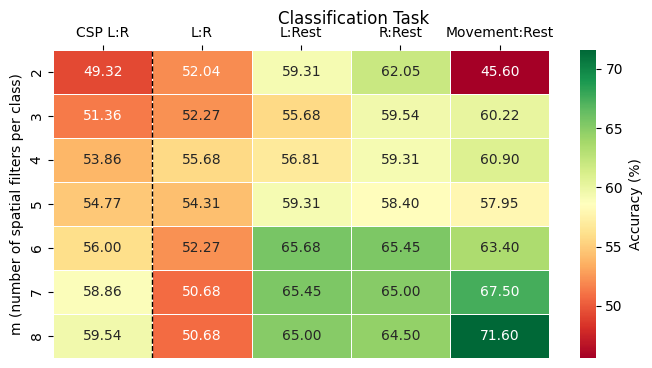

ImportError: cannot import name 'lfilter' from 'scipy.signal._signaltools' (C:\Users\LENOVO\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\scipy\signal\_signaltools.py)

In [11]:
# Band pass filter with butterworth filter
from scipy.signal import butter, lfilter
from scipy.signal import freqz

In [ ]:
def butter_bandpass_filter(signal, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut/nyq
    high = highcut/nyq
    b,a = butter(order, [low, high], btype='band')
    y = lfilter(b, a, signal, axis=-1)
    
    return y

### Filtering EEG signal with Butterworth Band-pass - FBCSP
Following the steps mentioned in [1], there will be 8 band-pass filter with bandwidth of:
1. 4-8Hz
2. 8-12Hz
3. 12-16Hz
4. 16-20Hz
5. 20-24Hz
6. 24-28Hz
7. 28-32Hz
8. 32-36Hz
9. 36-40Hz

*Note*   
Apply filter to the time-series axis, thus set 'raw_EEG' inside each subject to shape of N x T (i.e. electrodes x samples)

In [ ]:
# Transpose all 'raw_EEG' data
for i in range(1, ns):
    subj = subject_counter(i)
    
    while mod_data[subj]['raw_EEG'].shape[0] != 22:
        mod_data[subj]['raw_EEG'] = mod_data[subj]['raw_EEG'].T


In [ ]:
# Create function that could bandpass filtered one subject
def butter_bandpass_one_subject(data, subj, lowcut, highcut, fs, interval=None):
    print('Processing ', subj)
    
    # Create new key 'EEG_filtered' to store filtered EEG of each subject
    data[subj]['EEG_filtered'] = {}
    
    # Current raw EEG
    temp_raw_EEG = data[subj]['raw_EEG']
    
    if interval is not None:
        startband = np.arange(lowcut, highcut, step = interval)
        
        for start in startband:
            # This will be new key inside the EEG_filtered
            band = "{:02d}_{:02d}".format(start, start+interval)
            
            print('Filtering through {} Hz band'.format(band))
            # Bandpass filtering
            data[subj]['EEG_filtered'][band] = {}
            data[subj]['EEG_filtered'][band]['EEG_all'] = butter_bandpass_filter(temp_raw_EEG, start, start+interval, fs)
            
    else:
        # This will be new key inside the EEG_filtered
        band = "{:02d}_{:02d}".format(lowcut, highcut)
        
        data[subj]['EEG_filtered'][band]['EEG_all'] = butter_bandpass_filter(temp_raw_EEG, lowcut, highcut, fs)

In [ ]:
# Bandpass filtering all subject 
lowcut=4
highcut=40
fs = 250

# Iterate over all subjects
for i in range(sub_start, sub_end):
    subj = subject_counter(i)
    butter_bandpass_one_subject(mod_data, subj, lowcut, highcut, fs, interval=4)
    print('')

Processing  subject01
Filtering through 04_08 Hz band
Filtering through 08_12 Hz band
Filtering through 12_16 Hz band
Filtering through 16_20 Hz band
Filtering through 20_24 Hz band
Filtering through 24_28 Hz band
Filtering through 28_32 Hz band
Filtering through 32_36 Hz band
Filtering through 36_40 Hz band

Processing  subject02
Filtering through 04_08 Hz band
Filtering through 08_12 Hz band
Filtering through 12_16 Hz band
Filtering through 16_20 Hz band
Filtering through 20_24 Hz band
Filtering through 24_28 Hz band
Filtering through 28_32 Hz band
Filtering through 32_36 Hz band
Filtering through 36_40 Hz band

Processing  subject03
Filtering through 04_08 Hz band
Filtering through 08_12 Hz band
Filtering through 12_16 Hz band
Filtering through 16_20 Hz band
Filtering through 20_24 Hz band
Filtering through 24_28 Hz band
Filtering through 28_32 Hz band
Filtering through 32_36 Hz band
Filtering through 36_40 Hz band

Processing  subject04
Filtering through 04_08 Hz band
Filtering thr

## Taking EEG data corresponds to selected classes
Band-filtered EEG first and second of each class of shape T x C x N, where  
T = trial, C = channel, N = sample

In [ ]:
# Take the position of both selected class
# first_class_code = 770
# second_class_code = [769, 771, 772]  # List of possible labels for the second class

for i in range(1, ns):
    subj = subject_counter(i)
    
    mod_data[subj]['first_pos'] = ori_data[subj]['epos'][np.isin(ori_data[subj]['etyp'], first_class_code)] # 
    mod_data[subj]['second_pos'] = ori_data[subj]['epos'][np.isin(ori_data[subj]['etyp'], second_class_code)]

# Automated FBCSP implementation and processing for all classifications


========== Running classification: Left vs Right ==========

Processing  subject01
Processing  subject02
Processing  subject03
Processing  subject04
Processing  subject05
Processing  subject06
Processing  subject07
Processing  subject08
Processing  subject09
Storing 'all_band' for subject subject01
Storing 'all_band' for subject subject02
Storing 'all_band' for subject subject03
Storing 'all_band' for subject subject04
Storing 'all_band' for subject subject05
Storing 'all_band' for subject subject06
Storing 'all_band' for subject subject07
Storing 'all_band' for subject subject08
Storing 'all_band' for subject subject09
Processing for subject01
Processing for subject02
Processing for subject03
Processing for subject04
Processing for subject05
Processing for subject06
Processing for subject07
Processing for subject08
Processing for subject09


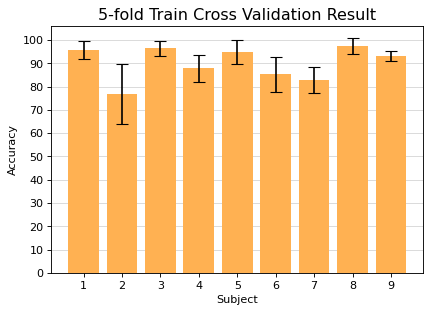

====== Accuracy for all subjects ======
Subject01 : 95.69 % +/- 3.89
Subject02 : 76.85 % +/- 12.69
Subject03 : 96.56 % +/- 3.24
Subject04 : 87.93 % +/- 5.76
Subject05 : 94.78 % +/- 5.07
Subject06 : 85.29 % +/- 7.64
Subject07 : 82.68 % +/- 5.61
Subject08 : 97.39 % +/- 3.48
Subject09 : 93.12 % +/- 2.08


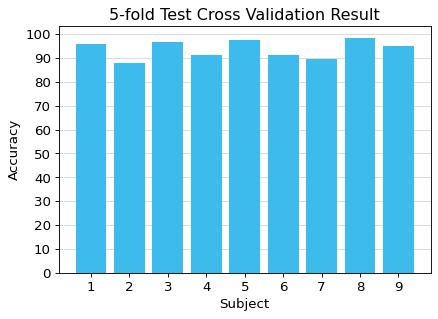

====== Test Accuracy for all subjects ======
Subject01 : 95.69 %
Subject02 : 87.93 %
Subject03 : 96.55 %
Subject04 : 91.38 %
Subject05 : 97.41 %
Subject06 : 91.38 %
Subject07 : 89.66 %
Subject08 : 98.28 %
Subject09 : 94.83 %

====== Cross-Validation Results - Left : Right ======
subject01: Mean Accuracy = 96.43%, Std = 7.14%
subject02: Mean Accuracy = 90.05%, Std = 16.53%
subject03: Mean Accuracy = 97.14%, Std = 5.71%
subject04: Mean Accuracy = 90.02%, Std = 18.28%
subject05: Mean Accuracy = 96.43%, Std = 7.14%
subject06: Mean Accuracy = 91.43%, Std = 17.14%
subject07: Mean Accuracy = 92.86%, Std = 14.29%
subject08: Mean Accuracy = 99.29%, Std = 1.43%
subject09: Mean Accuracy = 98.62%, Std = 2.76%

Overall Mean Accuracy: 94.70%
Overall Standard Deviation: 10.05%

========== Running classification: Left vs Rest ==========

Processing  subject01
Processing  subject02
Processing  subject03
Processing  subject04
Processing  subject05


In [ ]:
all_results = []

for first_class_code, second_class_code, label1, label2 in classification_combinations:
    print(f"\n========== Running classification: {label1} vs {label2} ==========\n")

    for i in range(1, ns):
        subj = subject_counter(i)
        
        mod_data[subj]['first_pos'] = ori_data[subj]['epos'][np.isin(ori_data[subj]['etyp'], first_class_code)] # 
        mod_data[subj]['second_pos'] = ori_data[subj]['epos'][np.isin(ori_data[subj]['etyp'], second_class_code)]

# %%
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        print('Processing ', subj)

        # Temporary variable of first and second pos    
        temp_pos_first = mod_data[subj]['first_pos']
        temp_pos_second = mod_data[subj]['second_pos']
    
        for band in mod_data[subj]['EEG_filtered'].keys():
            temp_EEG_all = mod_data[subj]['EEG_filtered'][band]['EEG_all']
            temp_EEG_first = []
            temp_EEG_second = []
            
            # first
            for j in range(len(temp_pos_first)):
                temp_EEG_first.append(temp_EEG_all[:, temp_pos_first[j] + int(start*fs) : temp_pos_first[j] + int(end*fs)])
            mod_data[subj]['EEG_filtered'][band]['EEG_first'] = np.array(temp_EEG_first)
            
            # second
            for j in range(len(temp_pos_second)):
                temp_EEG_second.append(temp_EEG_all[:, temp_pos_second[j] + int(start*fs) : temp_pos_second[j] + int(end*fs)])
            mod_data[subj]['EEG_filtered'][band]['EEG_second'] = np.array(temp_EEG_second)

    # %% [markdown]
    # # Train/Test Data Split

    # %%
    def split_EEG_one_class(EEG_one_class, percent_train=0.8):
        '''
        split_EEG_one_class will receive EEG data of one class, with size of T x N x M, where
        T = number of trial
        N = number of electrodes
        M = sample number
        
        INPUT:
        EEG_data_one_class: the data of one class of EEG data
        
        percent_train: allocation percentage of training data, default is 0.8
        
        OUTPUT:
        EEG_train: EEG data for training
        
        EEG_test: EEG data for test
        
        Both have type of np.arrray dimension of T x M x N
        '''

        # Number of all trials
        n = EEG_one_class.shape[0]
        
        n_tr = round(n*percent_train)
        n_te = n - n_tr
        
        EEG_train = EEG_one_class[:n_tr]
        EEG_test = EEG_one_class[n_tr:n_tr+n_te]
            
        return EEG_train, EEG_test

    # %%
    # Iterate over all subjects
    for i in range(sub_start, sub_end):
        
        subj = subject_counter(i)
        
        # Iterate over all bands
        for band in mod_data[subj]['EEG_filtered'].keys():
            
            # Temporary variable for each of each band
            temp_EEG_first = mod_data[subj]['EEG_filtered'][band]['EEG_first']
            temp_EEG_second = mod_data[subj]['EEG_filtered'][band]['EEG_second']

            # Temporary variable to access each band
            temp_filt = mod_data[subj]['EEG_filtered'][band]
            
            temp_filt['EEG_first_train'], temp_filt['EEG_first_test'] = split_EEG_one_class(temp_EEG_first, 0.8)
            temp_filt['EEG_second_train'], temp_filt['EEG_second_test'] = split_EEG_one_class(temp_EEG_second, 0.8)  

    # %% [markdown]
    # # CSP
    # This step will perform CSP on each band of each subject

    # %%
    # For all subject create new keys to store all result in CSP step
    for i in range(1, ns):
        subj = subject_counter(i)
        
        mod_data[subj]['CSP'] = {}

    # %% [markdown]
    # ## Covariance and Composite Covariance

    # %%
    def compute_cov(EEG_data):
        '''
        INPUT:
        EEG_data : EEG_data in shape T x N x S
        
        OUTPUT:
        avg_cov : covariance matrix of averaged over all trials
        '''
        cov = []
        for i in range(EEG_data.shape[0]):
            cov.append(EEG_data[i]@EEG_data[i].T/np.trace(EEG_data[i]@EEG_data[i].T))
            
        cov = np.mean(np.array(cov), 0)
        
        return cov

    # %%
    # Iterate over all subjects
    for i in range(sub_start, sub_end):
        
        subj = subject_counter(i)
        
        # Iterate over all bands
        for band in mod_data[subj]['EEG_filtered'].keys():
            
            # New key to store result
            temp_band = mod_data[subj]['CSP'][band] = {}
            
            # Compute classes covariance
            # Class 1
            temp_band['cov_first'] = compute_cov(mod_data[subj]['EEG_filtered'][band]['EEG_first_train'])
            
            # Class 2
            temp_band['cov_second'] = compute_cov(mod_data[subj]['EEG_filtered'][band]['EEG_second_train'])
            
            # Add covariances as composite covariance
            temp_band['cov_comp'] = temp_band['cov_first'] + temp_band['cov_second']

    # %%
    temp1 = mod_data['subject03']['CSP']['04_08']['cov_first']
    temp2 = mod_data['subject03']['CSP']['04_08']['cov_second']
    temp3 = mod_data['subject03']['CSP']['04_08']['cov_comp']

    # %% [markdown]
    # ## White Matrix (P)

    # %%
    # Create new keys for result in whitening step
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        for band in mod_data[subj]['EEG_filtered'].keys():
            mod_data[subj]['CSP'][band]['whitening'] = {}

    # %%
    from scipy.linalg import sqrtm
    from scipy.linalg import inv

    # %%
    def decompose_cov(avg_cov):
        '''
        This function will decompose average covariance matrix of one class of each subject into 
        eigenvalues denoted by lambda and eigenvector denoted by V
        Both will be in descending order
        
        Parameter:
        avgCov = the averaged covariance of one class
        
        Return:
        λ_dsc and V_dsc, i.e. eigenvalues and eigenvector in descending order
        
        '''
        λ, V = np.linalg.eig(avg_cov)
        λ_dsc = np.sort(λ)[::-1] # Sort eigenvalue descending order, default is ascending order sort
        idx_dsc = np.argsort(λ)[::-1] # Find index in descending order
        V_dsc = V[:, idx_dsc] # Sort eigenvectors descending order
        λ_dsc = np.diag(λ_dsc) # Diagonalize λ_dsc
        
        return λ_dsc, V_dsc

    # %%
    def white_matrix(λ_dsc, V_dsc):
        '''
        '''
        λ_dsc_sqr = sqrtm(inv(λ_dsc))
        P = (λ_dsc_sqr)@(V_dsc.T)
        
        return P

    # %%
    # Iterate over all subject compute whitening matrix
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        for band in mod_data[subj]['EEG_filtered'].keys():
            
            temp_whitening = mod_data[subj]['CSP'][band]['whitening']

            temp_cov = mod_data[subj]['CSP'][band]['cov_comp']

            # Decomposing composite covariance into eigenvector and eigenvalue
            temp_whitening['eigval'], temp_whitening['eigvec'] = decompose_cov(temp_cov)

            # White matrix
            temp_whitening['P'] = white_matrix(temp_whitening['eigval'], temp_whitening['eigvec'])

    # %% [markdown]
    # ## Common Eigenvec from Sl and Sr
    # In this step the Sl and Sr will not be stored, will only be used to compute each eigenvector

    # %%
    # Create new keys for result in whitening step
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        for band in mod_data[subj]['EEG_filtered'].keys():
            mod_data[subj]['CSP'][band]['S_first'] = {}
            mod_data[subj]['CSP'][band]['S_second'] = {}  

    # %%
    def compute_S(avg_Cov, white):
        '''
        This function will compute S matrix, S = P * C * P.T

        INPUT:
        avg_Cov: averaged covariance of one class, dimension N x N, where N is number of electrodes
        white: the whitening transformation matrix
        
        OUTPUT:
        S
        '''
        S = white@avg_Cov@white.T
        
        return S

    # %%
    def decompose_S(S_one_class, order='descending'):
        '''
        This function will decompose the S matrix of one class to get the eigen vector
        Both eigenvector will be the same but in opposite order
        
        i.e the highest eigenvector in S first will be equal to lowest eigenvector in S second matrix 
        '''
        # Decompose S
        λ, B = np.linalg.eig(S_one_class)
        
        # Sort eigenvalues either descending or ascending
        if order == 'ascending':
            idx = λ.argsort() # Use this index to sort eigenvector smallest -> largest
        elif order == 'descending':
            idx = λ.argsort()[::-1] # Use this index to sort eigenvector largest -> smallest
        else:
            print('Wrong order input')
        
        λ = λ[idx]
        B = B[:, idx]
        
        return B, λ 

    # %%
    # Iterate over all subjects
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        for band in mod_data[subj]['EEG_filtered'].keys():
            # Where to access data
            temp_P = mod_data[subj]['CSP'][band]['whitening']['P']
            Cl = mod_data[subj]['CSP'][band]['cov_first']
            Cr = mod_data[subj]['CSP'][band]['cov_second']

            # Where to store result
            temp_Sl = mod_data[subj]['CSP'][band]['S_first']
            temp_Sr = mod_data[subj]['CSP'][band]['S_second']

            # first
            Sl = compute_S(Cl, temp_P)
            temp_Sl['eigvec'], temp_Sl['eigval'] = decompose_S(Sl, 'descending')

            # second
            Sr = compute_S(Cr, temp_P)
            temp_Sr['eigvec'], temp_Sr['eigval'] = decompose_S(Sr, 'ascending')   

    # %% [markdown]
    # ## Spatial Filter (W)
    # Will compute the spatial filter of each subject of each band

    # %%
    def spatial_filter(B, P):
        '''
        Will compute projection matrix using the following equation:
        W = B' @ P
        
        INPUT:
        B: the eigenvector either first or second class, choose one !, size N x N, N is number of electrodes
        P: white matrix in size of N x N 
        
        OUTPUT:
        W spatial filter to filter EEG
        '''
        
        return (B.T@P)

    # %%
    # Iterate over all subject
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        for band in mod_data[subj]['EEG_filtered'].keys():
            temp_eigvec = mod_data[subj]['CSP'][band]['S_first']['eigvec']
            temp_P = mod_data[subj]['CSP'][band]['whitening']['P']

            mod_data[subj]['CSP'][band]['W'] = spatial_filter(temp_eigvec, temp_P)

    # %% [markdown]
    # # Feature Vector Train

    # %%
    # Create new keys for trainning and test feature vector
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        mod_data[subj]['train'] = {}
        mod_data[subj]['test'] = {}
        
        for band in mod_data[subj]['EEG_filtered'].keys():
            mod_data[subj]['train'][band] = {}
            mod_data[subj]['test'][band] = {}       

    # %%
    def compute_Z(W, E, m):
        '''
        Will compute the Z
        Z = W @ E, 
        
        E is in the shape of N x M, N is number of electrodes, M is sample
        In application, E has nth trial, so there will be n numbers of Z
        
        Z, in each trial will have dimension of m x M, 
        where m is the first and last m rows of W, corresponds to smallest and largest eigenvalues
        '''
        Z = []
        
        W = np.delete(W, np.s_[m:-m:], 0)
        
        for i in range(E.shape[0]):
            Z.append(W @ E[i])
        
        return np.array(Z)

    # %%
    def feat_vector(Z):
        '''
        Will compute the feature vector of Z matrix
        
        INPUT:
        Z : projected EEG shape of T x N x S
        
        OUTPUT:
        feat : feature vector shape of T x m
        
        T = trial
        N = channel
        S = sample
        m = number of filter
        '''
        
        feat = []
        
        for i in range(Z.shape[0]):
            var = np.var(Z[i], ddof=1, axis=1)
            varsum = np.sum(var)
            
            feat.append(np.log10(var/varsum))
            
        return np.array(feat)

    # %%
    # Iterate over all subjects
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        for band in mod_data[subj]['EEG_filtered'].keys():
            temp_W = mod_data[subj]['CSP'][band]['W']
            temp_EEG_first = mod_data[subj]['EEG_filtered'][band]['EEG_first_train']
            temp_EEG_second = mod_data[subj]['EEG_filtered'][band]['EEG_second_train']

            # first
            mod_data[subj]['train'][band]['Z_first'] = compute_Z(temp_W, temp_EEG_first, m)
            mod_data[subj]['train'][band]['feat_first'] = feat_vector(mod_data[subj]['train'][band]['Z_first'])

            first_label = np.zeros([len(mod_data[subj]['train'][band]['feat_first']), 1])
            
            # second
            mod_data[subj]['train'][band]['Z_second'] = compute_Z(temp_W, temp_EEG_second, m)
            mod_data[subj]['train'][band]['feat_second'] = feat_vector(mod_data[subj]['train'][band]['Z_second'])
            
            second_label = np.ones([len(mod_data[subj]['train'][band]['feat_second']), 1])
            
            first  = np.c_[mod_data[subj]['train'][band]['feat_first'], first_label]
            second  = np.c_[mod_data[subj]['train'][band]['feat_second'], second_label] 
            
            mod_data[subj]['train'][band]['feat_train'] = np.vstack([first, second])
            
            np.random.shuffle(mod_data[subj]['train'][band]['feat_train'])

    # %% [markdown]
    # ## Merging Train Feature of All Bandwidth
    # Merging all feature of each bandpass horizontally  
    # This will result in an array with shape of T x (9 * 2m) without true label  
    # where m is the number of filter, and T is number of trials

    # %%
    # Iterate over all subjects
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        # Check if subject exists in mod_data
        if subj not in mod_data:
            print(f"Subject {subj} not found in mod_data")
            continue  # Skip this subject if it doesn't exist in mod_data
        
        # Initialize train key if not present
        if 'train' not in mod_data[subj]:
            mod_data[subj]['train'] = {}
        
        feat_first_all = []
        feat_second_all = []
        
        for band in mod_data[subj]['EEG_filtered'].keys():
            # Access features for each band of the first class
            feat_first = mod_data[subj]['train'][band]['feat_first']
            feat_first_all.append(feat_first)
            
            # Access features for each band of the second class
            feat_second = mod_data[subj]['train'][band]['feat_second']
            feat_second_all.append(feat_second)
        
        # MERGING FEATURES FIRST CLASS
        merge_first = np.hstack(feat_first_all)  # Stack all arrays horizontally in one go
        merge_first = merge_first[:, 2*m:]  # Remove initial zeros (slice out the first 2*m columns)

        # MERGING FEATURES SECOND CLASS
        merge_second = np.hstack(feat_second_all)  # Stack all arrays horizontally in one go
        merge_second = merge_second[:, 2*m:]  # Remove initial zeros (slice out the first 2*m columns)

        # TRUE LABELS
        true_first = np.zeros([merge_first.shape[0], 1])
        true_second = np.ones([merge_second.shape[0], 1])

        # FEATURE + TRUE LABEL
        first = np.hstack([merge_first, true_first])
        second = np.hstack([merge_second, true_second])

        # MERGE CLASSES
        train_feat = np.vstack([first, second])

        # Shuffle the final training data
        np.random.shuffle(train_feat)

        # Check if 'all_band' exists in the 'train' key and store the result
        if 'all_band' not in mod_data[subj]['train']:
            print(f"Storing 'all_band' for subject {subj}")
            mod_data[subj]['train']['all_band'] = train_feat
        else:
            print(f"'all_band' already exists for subject {subj}. Overwriting data.")
            mod_data[subj]['train']['all_band'] = train_feat


    # %% [markdown]
    # ## Mutual Based Information (MI) to Select Most Informative Band

    # %%
    from sklearn.feature_selection import mutual_info_classif
    from sklearn.feature_selection import SelectKBest

    # %%
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        X_train = mod_data[subj]['train']['all_band'][:, :-1]
        y_train = mod_data[subj]['train']['all_band'][:, -1]
        
        # New dictionary to store result
        mod_data[subj]['train']['mutual'] = {}
        
        # Use mutual information to find 4 most informative feature
        select = SelectKBest(mutual_info_classif, k = 4).fit(X_train, y_train)
        mod_data[subj]['train']['mutual']['X'] = X_train[:, select.get_support()]
        mod_data[subj]['train']['mutual']['y'] = y_train    

    # %% [markdown]
    # # Feature Vector Test

    # %%
    # Seed to fix randomization
    np.random.seed(42)

    # Iterate over all subjects
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        for band in mod_data[subj]['EEG_filtered'].keys():
            temp_W = mod_data[subj]['CSP'][band]['W']
            temp_EEG_first = mod_data[subj]['EEG_filtered'][band]['EEG_first_test']
            temp_EEG_second = mod_data[subj]['EEG_filtered'][band]['EEG_second_test']

            # first
            mod_data[subj]['test'][band]['Z_first'] = compute_Z(temp_W, temp_EEG_first, m)
            mod_data[subj]['test'][band]['feat_first'] = feat_vector(mod_data[subj]['test'][band]['Z_first'])

            first_label = np.zeros([len(mod_data[subj]['test'][band]['feat_first']), 1])
            
            # second
            mod_data[subj]['test'][band]['Z_second'] = compute_Z(temp_W, temp_EEG_second, m)
            mod_data[subj]['test'][band]['feat_second'] = feat_vector(mod_data[subj]['test'][band]['Z_second'])
                            
            second_label = np.ones([len(mod_data[subj]['test'][band]['feat_second']), 1])

            # MERGING 
            first  = np.c_[mod_data[subj]['test'][band]['feat_first'], first_label]
            second  = np.c_[mod_data[subj]['test'][band]['feat_second'], second_label] 
            
            mod_data[subj]['test'][band]['feat_test'] = np.vstack([first, second])
            
            np.random.shuffle(mod_data[subj]['test'][band]['feat_test'])

    # %% [markdown]
    # ## Merging Test Feature of All Bandwidth

    # %%
    # Iterate over all subjects
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        feat_first_all = []
        feat_second_all = []
        
        # Collecting the features for each band
        for band in mod_data[subj]['EEG_filtered'].keys():
            feat_first_all.append(mod_data[subj]['test'][band]['feat_first'])
            feat_second_all.append(mod_data[subj]['test'][band]['feat_second'])
        
        # MERGING FEATURES FOR FIRST CLASS
        merge_first = np.hstack(feat_first_all)  # Stack all arrays horizontally at once
        merge_first = merge_first[:, 2*m:]  # Slice out the first 2*m columns (to remove initial zeros)
        
        # MERGING FEATURES FOR SECOND CLASS
        merge_second = np.hstack(feat_second_all)  # Stack all arrays horizontally at once
        merge_second = merge_second[:, 2*m:]  # Slice out the first 2*m columns (to remove initial zeros)
        
        # TRUE LABELS
        true_first = np.zeros([merge_first.shape[0], 1])
        true_second = np.ones([merge_second.shape[0], 1])
        
        # FEATURE + TRUE LABEL
        first = np.hstack([merge_first, true_first])
        second = np.hstack([merge_second, true_second])
        
        # MERGE CLASSES
        test_feat = np.vstack([first, second])
        
        # Shuffle the final training data
        np.random.shuffle(test_feat)
        
        # Store the result
        mod_data[subj]['test']['all_band'] = test_feat

    # %%
    mod_data['subject03']['test']['all_band'].shape

    # %% [markdown]
    # ## Mutual Based Information (MI) to Select Most Informative Band

    # %%
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        X_test = mod_data[subj]['test']['all_band'][:, :-1]
        y_test = mod_data[subj]['test']['all_band'][:, -1]
        
        # New dictionary to store result
        mod_data[subj]['test']['mutual'] = {}
        
        # Use mutual information to find 4 most informative feature
        select = SelectKBest(mutual_info_classif, k = 4).fit(X_test, y_test)
        mod_data[subj]['test']['mutual']['X'] = X_test[:, select.get_support()]
        mod_data[subj]['test']['mutual']['y'] = y_test    
        

    # %% [markdown]
    # # Classification

    # %%
    from sklearn.svm import SVC
    from sklearn.model_selection import cross_val_score

    # %%
    # Define model
    model = SVC(gamma='scale')

    # %% [markdown]
    # ## Evaluate Model Performance on Train Data

    # %%
    # Iterate over each subject
    eval_acc = []
    eval_std = []

    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        print('Processing for {}'.format(subj))
        X_train = mod_data[subj]['train']['mutual']['X']
        y_train = mod_data[subj]['train']['mutual']['y']
        
        eval_acc.append(cross_val_score(model, X_train, y_train, cv=5).mean()*100)
        eval_std.append(cross_val_score(model, X_train, y_train, cv=5).std()*100)

    # %%
    # Necessary variable to label x axis
    subject=[]
    for i in range(1, ns):
        subject.append(subject_counter(i))

    # %%
    fig, ax = plt.subplots(figsize=(6, 4), dpi=80)
    plt.rcParams.update({'font.size': 12})
    ax.set_title('Accuracy (%)')
    ax.grid(axis='y', alpha=0.5)
    ax.bar(np.arange(sub_start, sub_end), eval_acc, color="#ffb152", yerr=eval_std, capsize=5)
    ax.set(xticks=np.arange(sub_start, sub_end), xlabel='Subject', 
        yticks=np.arange(0, 101, step=10), ylabel='Accuracy',
        title='5-fold Train Cross Validation Result')
    ax.set_axisbelow(True)
    plt.savefig('5fold_train_result.jpg', bbox_inches='tight')
    plt.show()

    # Print each subject accuracy
    print("====== Accuracy for all subjects ======")
    for i in range(sub_end - sub_start):
        print("Subject{:02d} : {:.2f} % +/- {:.2f}".format(i+sub_start, eval_acc[i], eval_std[i]))

    # %% [markdown]
    # ## Result on Test Data
    # Based on initial observation, svc model performed well on train data. Thus we will proceed to use the current model to evaluate on test data 

    # %%
    # Blank list to store accuracy values
    train_score = []
    test_score = []

    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        # Prepare train and test data
        data_train = mod_data[subj]['train']['mutual']
        X_train = data_train['X']
        y_train = data_train['y']
        
        data_test = mod_data[subj]['test']['mutual']
        X_test = data_train['X']
        y_test = data_train['y']
        
        # Training the model + train accuracy
        model.fit(X_train, y_train)
        tr_score = model.score(X_train, y_train)*100
        te_score = model.score(X_test, y_test)*100
        
        train_score.append(tr_score)
        test_score.append(te_score)

    # %%
    fig, ax = plt.subplots(figsize=(6, 4), dpi=80)
    plt.rcParams.update({'font.size': 12})
    ax.set_title('Accuracy (%)')
    ax.grid(axis='y', alpha=0.5)
    ax.bar(np.arange(sub_start, sub_end), test_score, color="#3ebbed")
    ax.set(xticks=np.arange(sub_start, sub_end), xlabel='Subject', 
        yticks=np.arange(0, 101, step=10), ylabel='Accuracy',
        title='5-fold Test Cross Validation Result')
    ax.set_axisbelow(True)
    plt.savefig('5fold_test_result.jpg', bbox_inches='tight')
    plt.show()

    # Print each subject accuracy
    print("====== Test Accuracy for all subjects ======")
    for idx, i in enumerate(range(sub_start, sub_end)):
        print("Subject{:02d} : {:.2f} %".format(i, test_score[idx]))

    # %%
    # Conducting cross-validation on the entire dataset of a single subject, utilizing all frequency bands, for all the selected subjects
    # %%

    from sklearn.model_selection import cross_val_score

    # Perform cross-validation for each subject
    cv_results = {}

    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        # Combine train and test data
        X = np.vstack([mod_data[subj]['train']['all_band'][:, :-1], mod_data[subj]['test']['all_band'][:, :-1]])
        y = np.hstack([mod_data[subj]['train']['all_band'][:, -1], mod_data[subj]['test']['all_band'][:, -1]])
        
        # Perform cross-validation
        scores = cross_val_score(model, X, y, cv=5)
        cv_results[subj] = {
            'mean_accuracy': scores.mean() * 100,
            'std_accuracy': scores.std() * 100
        }

    # Display results
    print(f"\n====== Cross-Validation Results - {label1} : {label2} ======")
    all_mean_accuracies = []
    all_std_accuracies = []

    for subj, result in cv_results.items():
        print(f"{subj}: Mean Accuracy = {result['mean_accuracy']:.2f}%, Std = {result['std_accuracy']:.2f}%")
        all_mean_accuracies.append(result['mean_accuracy'])
        all_std_accuracies.append(result['std_accuracy'])

    # Calculate and display overall mean accuracy and standard deviation
    
    overall_mean_accuracy = np.mean(all_mean_accuracies)
    overall_std_accuracy = np.mean(all_std_accuracies)
    print(f"\nOverall Mean Accuracy: {overall_mean_accuracy:.2f}%")
    print(f"Overall Standard Deviation: {overall_std_accuracy:.2f}%")

    for idx, i in enumerate(range(sub_start, sub_end)):
        all_results.append({
            "Subject": f"Subject{i:02d}",
            "Classification": f"{label1} : {label2}",
            "Accuracy": test_score[idx]
        })


In [ ]:
# Comparison Table FBCSP
cv_results_table = {}

for result in all_results:
    subject = result["Subject"]
    classification = result["Classification"]
    accuracy = result["Accuracy"]

    if subject not in cv_results_table:
        cv_results_table[subject] = {}
    cv_results_table[subject][classification] = accuracy

# Convert to DataFrame
cv_results_df = pd.DataFrame(cv_results_table).T

# Print nicely
print("\n========== FBCSP Cross-Validation Results ==========")
print(cv_results_df)

# Calculate and display overall mean accuracy and standard deviation

overall_mean_accuracy = np.mean(all_mean_accuracies)
overall_std_accuracy = np.mean(all_std_accuracies)
print(f"\nOverall Mean Accuracy: {overall_mean_accuracy:.2f}%")
print(f"Overall Standard Deviation: {overall_std_accuracy:.2f}%")

for idx, i in enumerate(range(sub_start, sub_end)):
    all_results.append({
        "Subject": f"Subject{i:02d}",
        "Classification": f"{label1} : {label2}",
        "Accuracy": test_score[idx]
    })

# Save to CSV if desired
cv_results_df.to_csv("fbcsp_results.csv", index=True)


# CSP - Only Processing
Selected band is 8-30 Hz, since it covers both μ and β frequency band range, essential for the analysis

In [ ]:
print("\n========== Running CSP-Only Processing ==========\n")

# Create a copy of mod_data for CSP-only processing
csp_data = dict()
for i in range(1, ns):
    subj = subject_counter(i)
    csp_data[subj] = mod_data[subj].copy()
    csp_data[subj]['raw_EEG'] = mod_data[subj]['raw_EEG'].copy()

# Bandpass filter all subjects for CSP-only (8-30 Hz)
lowcut = 8
highcut = 30
fs = 250

# Clear existing filtered data
for i in range(1, ns):
    subj = subject_counter(i)
    csp_data[subj]['EEG_filtered'] = {}

# Apply single bandpass filter
for i in range(sub_start, sub_end):
    subj = subject_counter(i)
    print(f'Processing CSP-only for {subj}')
    
    # Create new key 'EEG_filtered' to store filtered EEG
    csp_data[subj]['EEG_filtered']['08_30'] = {}
    
    # Bandpass filtering (8-30 Hz)
    csp_data[subj]['EEG_filtered']['08_30']['EEG_all'] = butter_bandpass_filter(
        csp_data[subj]['raw_EEG'], lowcut, highcut, fs
    )

all_results_csp = []

for first_class_code, second_class_code, label1, label2 in classification_combinations:
    print(f"\n========== Running CSP-only classification: {label1} vs {label2} ==========\n")

    # Update event positions for current classification
    for i in range(1, ns):
        subj = subject_counter(i)
        csp_data[subj]['first_pos'] = ori_data[subj]['epos'][np.isin(ori_data[subj]['etyp'], first_class_code)]
        csp_data[subj]['second_pos'] = ori_data[subj]['epos'][np.isin(ori_data[subj]['etyp'], second_class_code)]

    # Extract EEG segments for selected classes
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        print('Processing ', subj)

        temp_pos_first = csp_data[subj]['first_pos']
        temp_pos_second = csp_data[subj]['second_pos']
    
        band = '08_30'  # Only one band for CSP-only, based on mi and beta bands
        temp_EEG_all = csp_data[subj]['EEG_filtered'][band]['EEG_all']
        temp_EEG_first = []
        temp_EEG_second = []
        
        # first class
        for j in range(len(temp_pos_first)):
            temp_EEG_first.append(temp_EEG_all[:, temp_pos_first[j] + int(start*fs) : temp_pos_first[j] + int(end*fs)])
        csp_data[subj]['EEG_filtered'][band]['EEG_first'] = np.array(temp_EEG_first)
        
        # second class
        for j in range(len(temp_pos_second)):
            temp_EEG_second.append(temp_EEG_all[:, temp_pos_second[j] + int(start*fs) : temp_pos_second[j] + int(end*fs)])
        csp_data[subj]['EEG_filtered'][band]['EEG_second'] = np.array(temp_EEG_second)

    # Train/Test split
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        band = '08_30'
        
        temp_EEG_first = csp_data[subj]['EEG_filtered'][band]['EEG_first']
        temp_EEG_second = csp_data[subj]['EEG_filtered'][band]['EEG_second']
        
        csp_data[subj]['EEG_filtered'][band]['EEG_first_train'], csp_data[subj]['EEG_filtered'][band]['EEG_first_test'] = split_EEG_one_class(temp_EEG_first, 0.8)
        csp_data[subj]['EEG_filtered'][band]['EEG_second_train'], csp_data[subj]['EEG_filtered'][band]['EEG_second_test'] = split_EEG_one_class(temp_EEG_second, 0.8)

    # Initialize CSP storage
    for i in range(1, ns):
        subj = subject_counter(i)
        csp_data[subj]['CSP'] = {}
        csp_data[subj]['CSP'][band] = {}

    # Compute covariance matrices
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        band = '08_30'
        
        # Compute classes covariance
        csp_data[subj]['CSP'][band]['cov_first'] = compute_cov(csp_data[subj]['EEG_filtered'][band]['EEG_first_train'])
        csp_data[subj]['CSP'][band]['cov_second'] = compute_cov(csp_data[subj]['EEG_filtered'][band]['EEG_second_train'])
        csp_data[subj]['CSP'][band]['cov_comp'] = csp_data[subj]['CSP'][band]['cov_first'] + csp_data[subj]['CSP'][band]['cov_second']

    # Whitening
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        band = '08_30'
        
        csp_data[subj]['CSP'][band]['whitening'] = {}
        temp_cov = csp_data[subj]['CSP'][band]['cov_comp']
        
        # Decomposing composite covariance
        csp_data[subj]['CSP'][band]['whitening']['eigval'], csp_data[subj]['CSP'][band]['whitening']['eigvec'] = decompose_cov(temp_cov)
        
        # White matrix
        csp_data[subj]['CSP'][band]['whitening']['P'] = white_matrix(
            csp_data[subj]['CSP'][band]['whitening']['eigval'], 
            csp_data[subj]['CSP'][band]['whitening']['eigvec']
        )

    # Compute S matrices
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        band = '08_30'
        
        csp_data[subj]['CSP'][band]['S_first'] = {}
        csp_data[subj]['CSP'][band]['S_second'] = {}  
        
        temp_P = csp_data[subj]['CSP'][band]['whitening']['P']
        Cl = csp_data[subj]['CSP'][band]['cov_first']
        Cr = csp_data[subj]['CSP'][band]['cov_second']

        # first class
        Sl = compute_S(Cl, temp_P)
        csp_data[subj]['CSP'][band]['S_first']['eigvec'], csp_data[subj]['CSP'][band]['S_first']['eigval'] = decompose_S(Sl, 'descending')

        # second class
        Sr = compute_S(Cr, temp_P)
        csp_data[subj]['CSP'][band]['S_second']['eigvec'], csp_data[subj]['CSP'][band]['S_second']['eigval'] = decompose_S(Sr, 'ascending')

    # Spatial filters
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        band = '08_30'
        
        temp_eigvec = csp_data[subj]['CSP'][band]['S_first']['eigvec']
        temp_P = csp_data[subj]['CSP'][band]['whitening']['P']
        
        csp_data[subj]['CSP'][band]['W'] = spatial_filter(temp_eigvec, temp_P)

    # Feature extraction for training data
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        csp_data[subj]['train'] = {}
        band = '08_30'
        
        temp_W = csp_data[subj]['CSP'][band]['W']
        temp_EEG_first = csp_data[subj]['EEG_filtered'][band]['EEG_first_train']
        temp_EEG_second = csp_data[subj]['EEG_filtered'][band]['EEG_second_train']

        # first class
        csp_data[subj]['train']['Z_first'] = compute_Z(temp_W, temp_EEG_first, m)
        csp_data[subj]['train']['feat_first'] = feat_vector(csp_data[subj]['train']['Z_first'])
        first_label = np.zeros([len(csp_data[subj]['train']['feat_first']), 1])
        
        # second class
        csp_data[subj]['train']['Z_second'] = compute_Z(temp_W, temp_EEG_second, m)
        csp_data[subj]['train']['feat_second'] = feat_vector(csp_data[subj]['train']['Z_second'])
        second_label = np.ones([len(csp_data[subj]['train']['feat_second']), 1])
        
        # Combine features and labels
        first = np.c_[csp_data[subj]['train']['feat_first'], first_label]
        second = np.c_[csp_data[subj]['train']['feat_second'], second_label]
        csp_data[subj]['train']['feat_train'] = np.vstack([first, second])
        np.random.shuffle(csp_data[subj]['train']['feat_train'])

    # Feature extraction for test data
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        csp_data[subj]['test'] = {}
        band = '08_30'
        
        temp_W = csp_data[subj]['CSP'][band]['W']
        temp_EEG_first = csp_data[subj]['EEG_filtered'][band]['EEG_first_test']
        temp_EEG_second = csp_data[subj]['EEG_filtered'][band]['EEG_second_test']

        # first class
        csp_data[subj]['test']['Z_first'] = compute_Z(temp_W, temp_EEG_first, m)
        csp_data[subj]['test']['feat_first'] = feat_vector(csp_data[subj]['test']['Z_first'])
        first_label = np.zeros([len(csp_data[subj]['test']['feat_first']), 1])
        
        # second class
        csp_data[subj]['test']['Z_second'] = compute_Z(temp_W, temp_EEG_second, m)
        csp_data[subj]['test']['feat_second'] = feat_vector(csp_data[subj]['test']['Z_second'])
        second_label = np.ones([len(csp_data[subj]['test']['feat_second']), 1])
        
        # Combine features and labels
        first = np.c_[csp_data[subj]['test']['feat_first'], first_label]
        second = np.c_[csp_data[subj]['test']['feat_second'], second_label]
        csp_data[subj]['test']['feat_test'] = np.vstack([first, second])
        np.random.shuffle(csp_data[subj]['test']['feat_test'])

    # Cross-validation for CSP-only
    cv_results_csp = {}
    
    for i in range(sub_start, sub_end):
        subj = subject_counter(i)
        
        # Combine train and test data for cross-validation
        X = np.vstack([
            csp_data[subj]['train']['feat_train'][:, :-1],
            csp_data[subj]['test']['feat_test'][:, :-1]
        ])
        y = np.hstack([
            csp_data[subj]['train']['feat_train'][:, -1],
            csp_data[subj]['test']['feat_test'][:, -1]
        ])
        
        # Perform cross-validation
        scores = cross_val_score(model, X, y, cv=5)
        cv_results_csp[subj] = {
            'mean_accuracy': scores.mean() * 100,
            'std_accuracy': scores.std() * 100
        }
        
        # Store results for comparison
        all_results_csp.append({
            "Subject": subj,
            "Classification": f"{label1} vs {label2}",
            "Accuracy": scores.mean() * 100,
            "Std": scores.std() * 100
        })

    # Display results for current classification
    print(f"\n====== CSP-Only Cross-Validation Results - {label1} vs {label2} ======")
    for subj, result in cv_results_csp.items():
        print(f"{subj}: Mean Accuracy = {result['mean_accuracy']:.2f}%, Std = {result['std_accuracy']:.2f}%")


In [ ]:
# Comparison table CSP 

csp_results_df = pd.DataFrame(all_results_csp)
csp_results_pivot = csp_results_df.pivot(index='Subject', columns='Classification', values='Accuracy')

# Calculate and display overall mean accuracy and standard deviation

# Print CSP results
print("\n========== CSP-Only Cross-Validation Results ==========")
print(csp_results_pivot)

overall_mean_accuracy = csp_results_df['Accuracy'].mean()
overall_std_accuracy = csp_results_df['Accuracy'].std()
print(f"\nOverall Mean Accuracy: {overall_mean_accuracy:.2f}%")
print(f"Overall Standard Deviation: {overall_std_accuracy:.2f}%")


# Save to CSV
csp_results_pivot.to_csv("csp_only_results.csv")

# Comparison tables FBCSP and CSP

In [ ]:
# Comparison Table FBCSP
cv_results_table = {}

for result in all_results:
    subject = result["Subject"]
    classification = result["Classification"]
    accuracy = result["Accuracy"]

    if subject not in cv_results_table:
        cv_results_table[subject] = {}
    cv_results_table[subject][classification] = accuracy

# Convert to DataFrame
cv_results_df = pd.DataFrame(cv_results_table).T

# Print nicely
print("\n========== FBCSP Cross-Validation Results ==========")
print(cv_results_df)

# Save to CSV if desired
cv_results_df.to_csv("fbcsp_results.csv", index=True)


# Comparison table CSP 

# Convert all_results_csp to a DataFrame
csp_results_df = pd.DataFrame(all_results_csp)

# Pivot the DataFrame to create a comparison table
csp_results_pivot = csp_results_df.pivot(index='Subject', columns='Classification', values='Accuracy')

# Print CSP results in a formatted way
print("\n========== CSP-Only Cross-Validation Results ==========")
print(csp_results_pivot.to_string(float_format="%.2f"))

# Save the results to a CSV file
output_file = "csp_only_results.csv"
csp_results_pivot.to_csv(output_file)
print(f"\nCSP-Only results saved to {output_file}")